# 🐍 8 nanobodies vs 17 serpientes letales

**¿Cuántas moléculas necesitas para frenar a las serpientes más peligrosas de África?**

Cada año, las mordeduras de serpientes cobran miles de vidas en África subsahariana. Los antivenenos actuales, derivados de plasma animal, son caros, provocan reacciones inmunológicas y no cubren todas las especies. Inmunizaron una alpaca y una llama con los venenos de 18 serpientes africanas, construyeron una biblioteca de anticuerpos miniatura (phage display) y encontraron 8 nanobodies que, combinados, neutralizan 7 familias de toxinas. Resultado en ratones: protección contra 17 de 18 especies, superando al antiveneno comercial en el experimento. Aún no hay ensayos clínicos en humanos.

---
📄 **Paper:** Ahmadi, S. *et al.* "Nanobody-based recombinant antivenom for cobra, mamba and rinkhals bites." *Nature* **647**, 716–725 (2025). [DOI: 10.1038/s41586-025-09661-0](https://doi.org/10.1038/s41586-025-09661-0)

▶️ **Video:** [Ver en YouTube](https://youtube.com/shorts/XnIsVcl8hoQ)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-nanobodies-antivenom-serpientes/notebook.ipynb)

## El desafío: venenos diversos, tratamientos limitados

África subsahariana alberga 18 serpientes elapidas médicamente relevantes. Se dividen en tres géneros — mambas (*Dendroaspis*), rinkhals (*Hemachatus*) y cobras (*Naja*) — y provocan dos cuadros clínicos opuestos: **parálisis neuromuscular** (mambas y cobras de capa) o **destrucción de tejido local** (cobras escupidoras y rinkhals).

La clave de esta diversidad clínica está en la composición del veneno. Veamos qué contienen.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_SERPIENTES = 18           # Especies elapidas africanas médicamente relevantes
N_NANOBODIES = 8            # Nanobodies en el antiveneno recombinante
N_PROTEGIDAS = 17           # Especies protegidas en pre-incubación
FUENTE = 'Fuente: Ahmadi et al. (2025), Nature 647 | Datos: Supplementary Table 1'

COLOR_3FTX = '#2563EB'      # Azul CaM — familia dominante
COLOR_CTX = '#DC2626'       # Rojo — citotoxinas (dermonecrosis)
COLOR_SNTX = '#D97706'      # Amber — neurotoxinas cortas
COLOR_LNTX = '#059669'      # Verde — neurotoxinas largas
COLOR_KUN = '#7C3AED'       # Violeta — Kunitz
COLOR_PLA2 = '#9333EA'      # Violeta oscuro — fosfolipasa
COLOR_OTRO = '#BBBBBB'      # Gris — otros

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
BASE_URL = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-01-17-nanobodies-antivenom-serpientes'
for fname in ['composicion_veneno.csv', 'resultados_in_vivo.csv', 'nanobodies.csv']:
    if not os.path.exists(f'datos/{fname}'):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE_URL}/datos/{fname}', f'datos/{fname}')

df = pd.read_csv('datos/composicion_veneno.csv')
df_vivo = pd.read_csv('datos/resultados_in_vivo.csv')
df_nb = pd.read_csv('datos/nanobodies.csv')

print(f"Composición de veneno: {len(df)} entradas de toxinas en {df['especie'].nunique()} especies")
print(f"Resultados in vivo: {len(df_vivo)} especies")
print(f"Nanobodies: {len(df_nb)} en el cocktail")

Composición de veneno: 133 entradas de toxinas en 16 especies
Resultados in vivo: 18 especies
Nanobodies: 8 en el cocktail


## Aquí están los venenos.

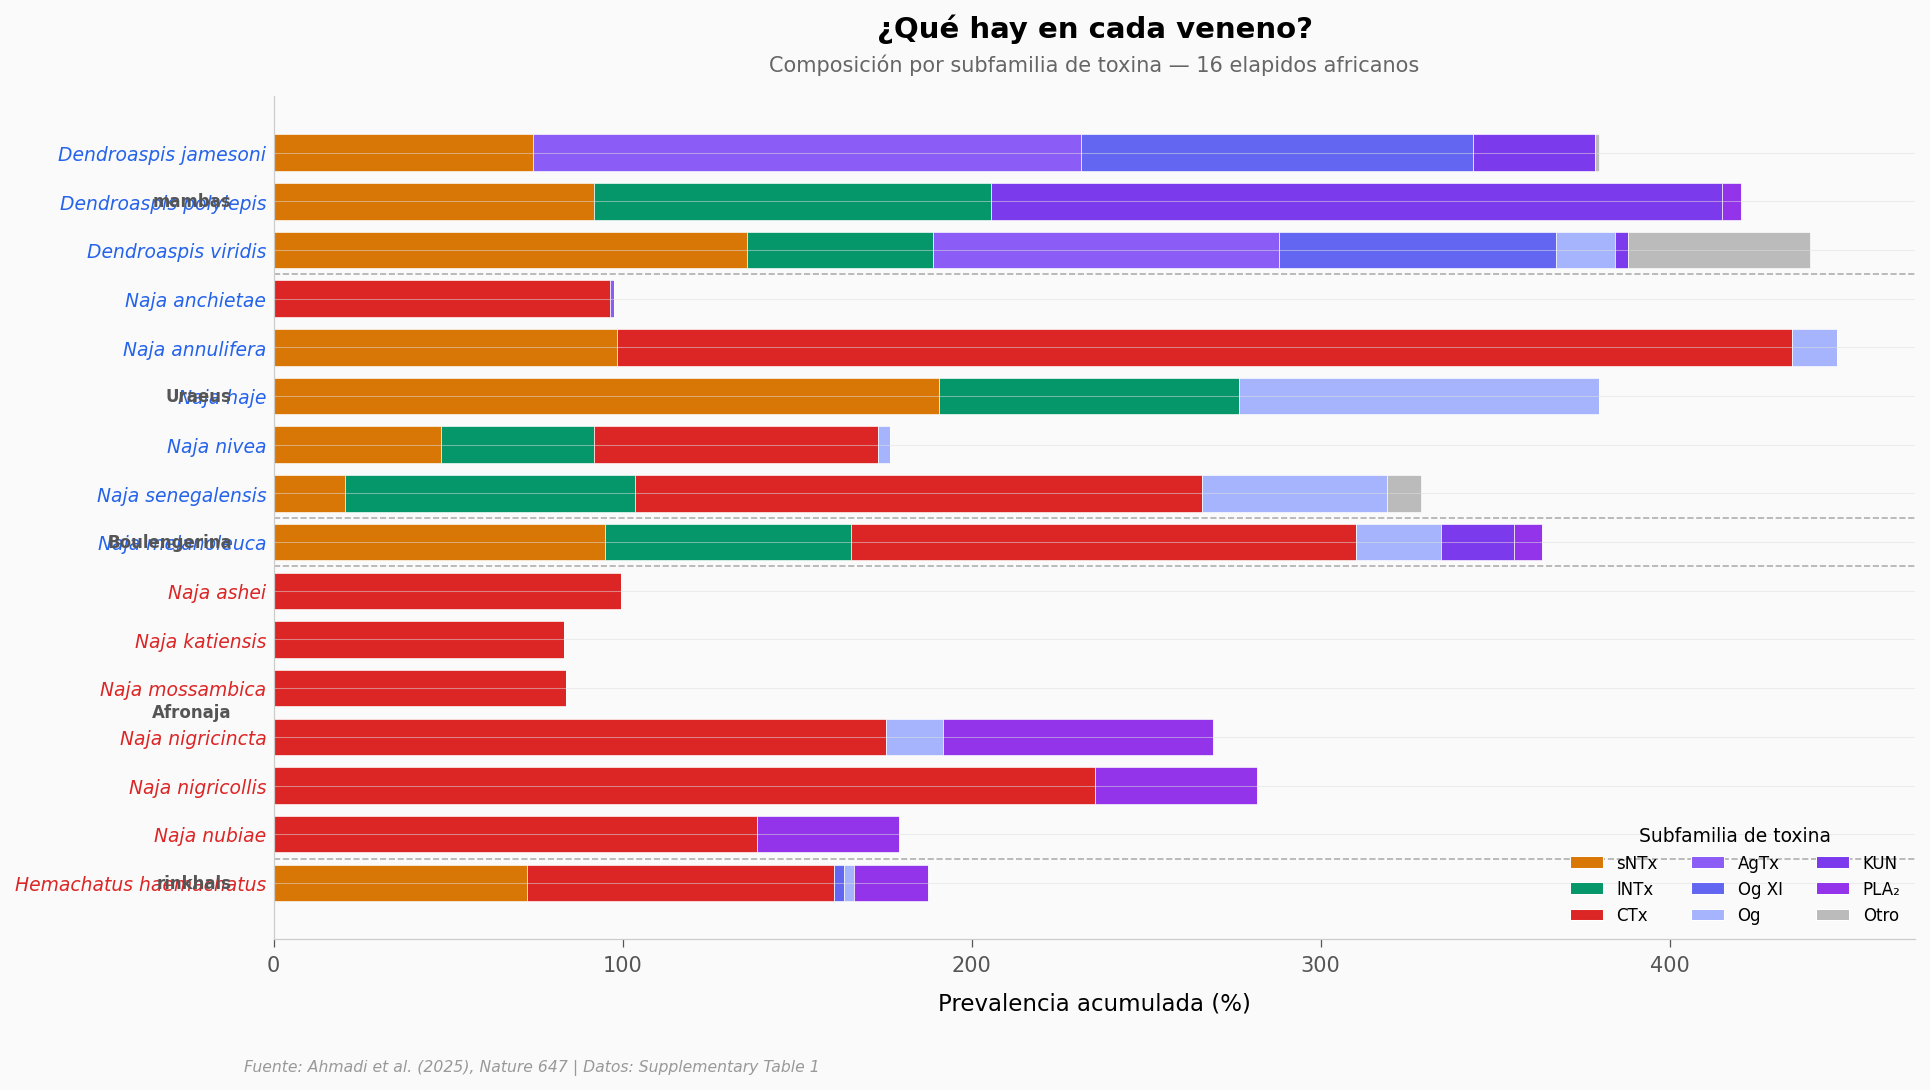

In [2]:
# Composición del veneno: ¿qué toxinas dominan en cada especie?
# Agrupamos por subfamilia de toxina y especie

# Agrupar subfamilias para visualización
def simplify_subfamily(fam):
    if 'sNTx' in fam: return 'sNTx'
    if 'lNTx' in fam: return 'lNTx'
    if 'CTx' in fam: return 'CTx'
    if 'AgTx' in fam: return 'AgTx'
    if 'Og XI' in fam: return 'Og XI'
    if 'Og' in fam: return 'Og'
    if 'KUN' in fam: return 'KUN'
    if 'PLA' in fam: return 'PLA₂'
    return 'Otro'

df['subfamilia'] = df['familia_toxina'].apply(simplify_subfamily)

# Calcular prevalencia media ponderada por especie y subfamilia
pivot = df.groupby(['especie', 'subfamilia'])['prevalencia_pct'].sum().reset_index()
pivot_wide = pivot.pivot(index='especie', columns='subfamilia', values='prevalencia_pct').fillna(0)

# Orden: por subgénero y luego por especie
subgenus_order = {
    'Dendroaspis (mambas)': 0, 'Naja (Uraeus)': 1, 'Naja (Boulengerina)': 2,
    'Naja (Afronaja)': 3, 'Hemachatus (rinkhals)': 4
}
sp_subgenus = df.drop_duplicates('especie').set_index('especie')['subgenero']
sp_syndrome = df.drop_duplicates('especie').set_index('especie')['sindrome']

species_sorted = sorted(pivot_wide.index,
    key=lambda s: (subgenus_order.get(sp_subgenus.get(s, ''), 5), s))
pivot_wide = pivot_wide.loc[species_sorted]

# Columnas en orden lógico
col_order = ['sNTx', 'lNTx', 'CTx', 'AgTx', 'Og XI', 'Og', 'KUN', 'PLA₂', 'Otro']
col_order = [c for c in col_order if c in pivot_wide.columns]
pivot_wide = pivot_wide[col_order]

# Colores para el heatmap
col_colors = {
    'sNTx': COLOR_SNTX, 'lNTx': COLOR_LNTX, 'CTx': COLOR_CTX,
    'AgTx': '#8B5CF6', 'Og XI': '#6366F1', 'Og': '#A5B4FC',
    'KUN': COLOR_KUN, 'PLA₂': COLOR_PLA2, 'Otro': COLOR_OTRO
}

fig, ax = plt.subplots(figsize=(13, 7))

# Stacked horizontal bar chart (más legible que heatmap para este caso)
left = np.zeros(len(species_sorted))
bars = {}
for col in col_order:
    vals = pivot_wide[col].values
    color = col_colors.get(col, COLOR_OTRO)
    bars[col] = ax.barh(range(len(species_sorted)), vals, left=left, color=color,
                        edgecolor='white', linewidth=0.3, height=0.75)
    left += vals

# Labels de especie con formato italics
ytick_labels = []
for sp in species_sorted:
    subg = sp_subgenus.get(sp, '')
    syndrome = sp_syndrome.get(sp, '')
    short = sp.split(' ')[1][:3].capitalize()
    ytick_labels.append(f'{sp}')

ax.set_yticks(range(len(species_sorted)))
ax.set_yticklabels(ytick_labels, fontsize=9, fontstyle='italic')

# Colorear ytick labels según síndrome
for i, sp in enumerate(species_sorted):
    syn = sp_syndrome.get(sp, '')
    color = COLOR_CTX if syn == 'Daño tisular local' else COLOR_3FTX
    ax.get_yticklabels()[i].set_color(color)

# Líneas separadoras de subgénero
prev_subg = None
for i, sp in enumerate(species_sorted):
    subg = sp_subgenus.get(sp, '')
    if prev_subg and subg != prev_subg:
        ax.axhline(y=i - 0.5, color='#666666', linewidth=0.8, linestyle='--', alpha=0.5)
    prev_subg = subg

# Anotar subgéneros
subg_positions = {}
for i, sp in enumerate(species_sorted):
    subg = sp_subgenus.get(sp, '')
    if subg not in subg_positions:
        subg_positions[subg] = []
    subg_positions[subg].append(i)

for subg, positions in subg_positions.items():
    mid = np.mean(positions)
    short_name = subg.split('(')[1].rstrip(')') if '(' in subg else subg
    ax.text(-12, mid, short_name, fontsize=8, fontweight='bold', ha='right', va='center',
            color='#555555')

ax.set_xlabel('Prevalencia acumulada (%)', fontsize=11)
ax.set_title('¿Qué hay en cada veneno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Composición por subfamilia de toxina — 16 elapidos africanos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(0, max(left) * 1.05)
ax.invert_yaxis()

# Leyenda
legend_elements = [mpatches.Patch(facecolor=col_colors[c], edgecolor='white', label=c) for c in col_order]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right',
          ncol=3, framealpha=0.9, title='Subfamilia de toxina', title_fontsize=9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/composicion_veneno.png', dpi=200, bbox_inches='tight')
plt.show()

### Dos mundos en un solo continente

El patrón es claro: las **mambas** (*Dendroaspis*) y las **cobras de capa** (*Naja* Uraeus) producen venenos dominados por neurotoxinas (sNTx, lNTx, AgTx), que causan **parálisis respiratoria**. Las **cobras escupidoras** (*Naja* Afronaja) y el **rinkhals** (*Hemachatus*) producen venenos cargados de citotoxinas (CTx), que destruyen tejido y provocan **dermonecrosis**.

Cualquier antiveneno universal necesita cubrir ambos perfiles. ¿Cómo lo logran con solo 8 moléculas?

## Los 8 nanobodies: una molécula por diana

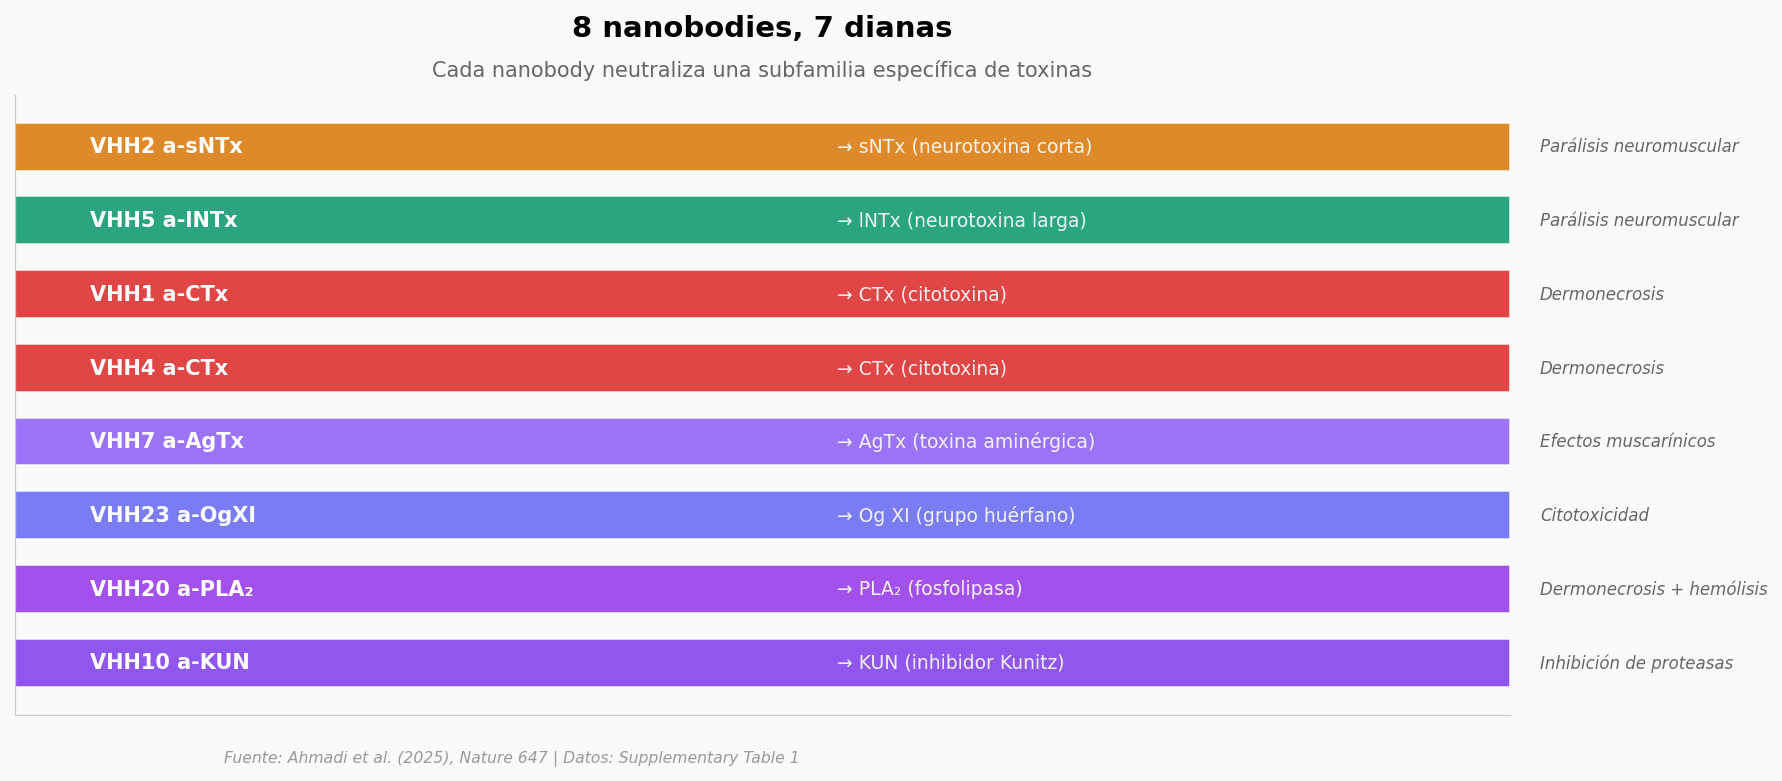

In [3]:
# ¿Qué cubre cada nanobody?
# Mapear los 8 nanobodies a las subfamilias de toxinas que neutralizan

fig, ax = plt.subplots(figsize=(12, 5))

# Datos de nanobodies
nb_names = df_nb['nanobody'].values
nb_targets = df_nb['diana'].values
nb_effects = df_nb['efecto_clinico'].values

# Colores por tipo de diana
target_colors = {
    'sNTx (neurotoxina corta)': COLOR_SNTX,
    'lNTx (neurotoxina larga)': COLOR_LNTX,
    'CTx (citotoxina)': COLOR_CTX,
    'AgTx (toxina aminérgica)': '#8B5CF6',
    'Og XI (grupo huérfano)': '#6366F1',
    'PLA₂ (fosfolipasa)': COLOR_PLA2,
    'KUN (inhibidor Kunitz)': COLOR_KUN,
}

# Horizontal bars
y_pos = range(len(nb_names))
colors = [target_colors.get(t, COLOR_OTRO) for t in nb_targets]
bars = ax.barh(y_pos, [1]*len(nb_names), color=colors, edgecolor='white',
               linewidth=0.8, height=0.65, alpha=0.85)

# Labels
for i, (name, target, effect) in enumerate(zip(nb_names, nb_targets, nb_effects)):
    ax.text(0.05, i, f'{name}', fontsize=10, fontweight='bold', va='center', color='white')
    ax.text(0.55, i, f'→ {target}', fontsize=9, va='center', color='white', alpha=0.9)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1)
ax.invert_yaxis()

ax.set_title('8 nanobodies, 7 dianas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada nanobody neutraliza una subfamilia específica de toxinas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotar efecto clínico a la derecha
for i, effect in enumerate(nb_effects):
    ax.text(1.02, i, effect, fontsize=8, va='center', color='#666666', fontstyle='italic',
            transform=ax.get_yaxis_transform())

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/nanobodies_dianas.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Funciona en un animal vivo?

La proteómica es prometedora, pero el veneno real es más que la suma de sus toxinas. Probaron el cocktail de 8 nanobodies en ratones con dos modelos:

- **Pre-incubación:** veneno + antiveneno mezclados antes de inyectar (mide capacidad de neutralización pura)
- **Rescate:** veneno inyectado primero, antiveneno 5 minutos después (simula una mordedura real)

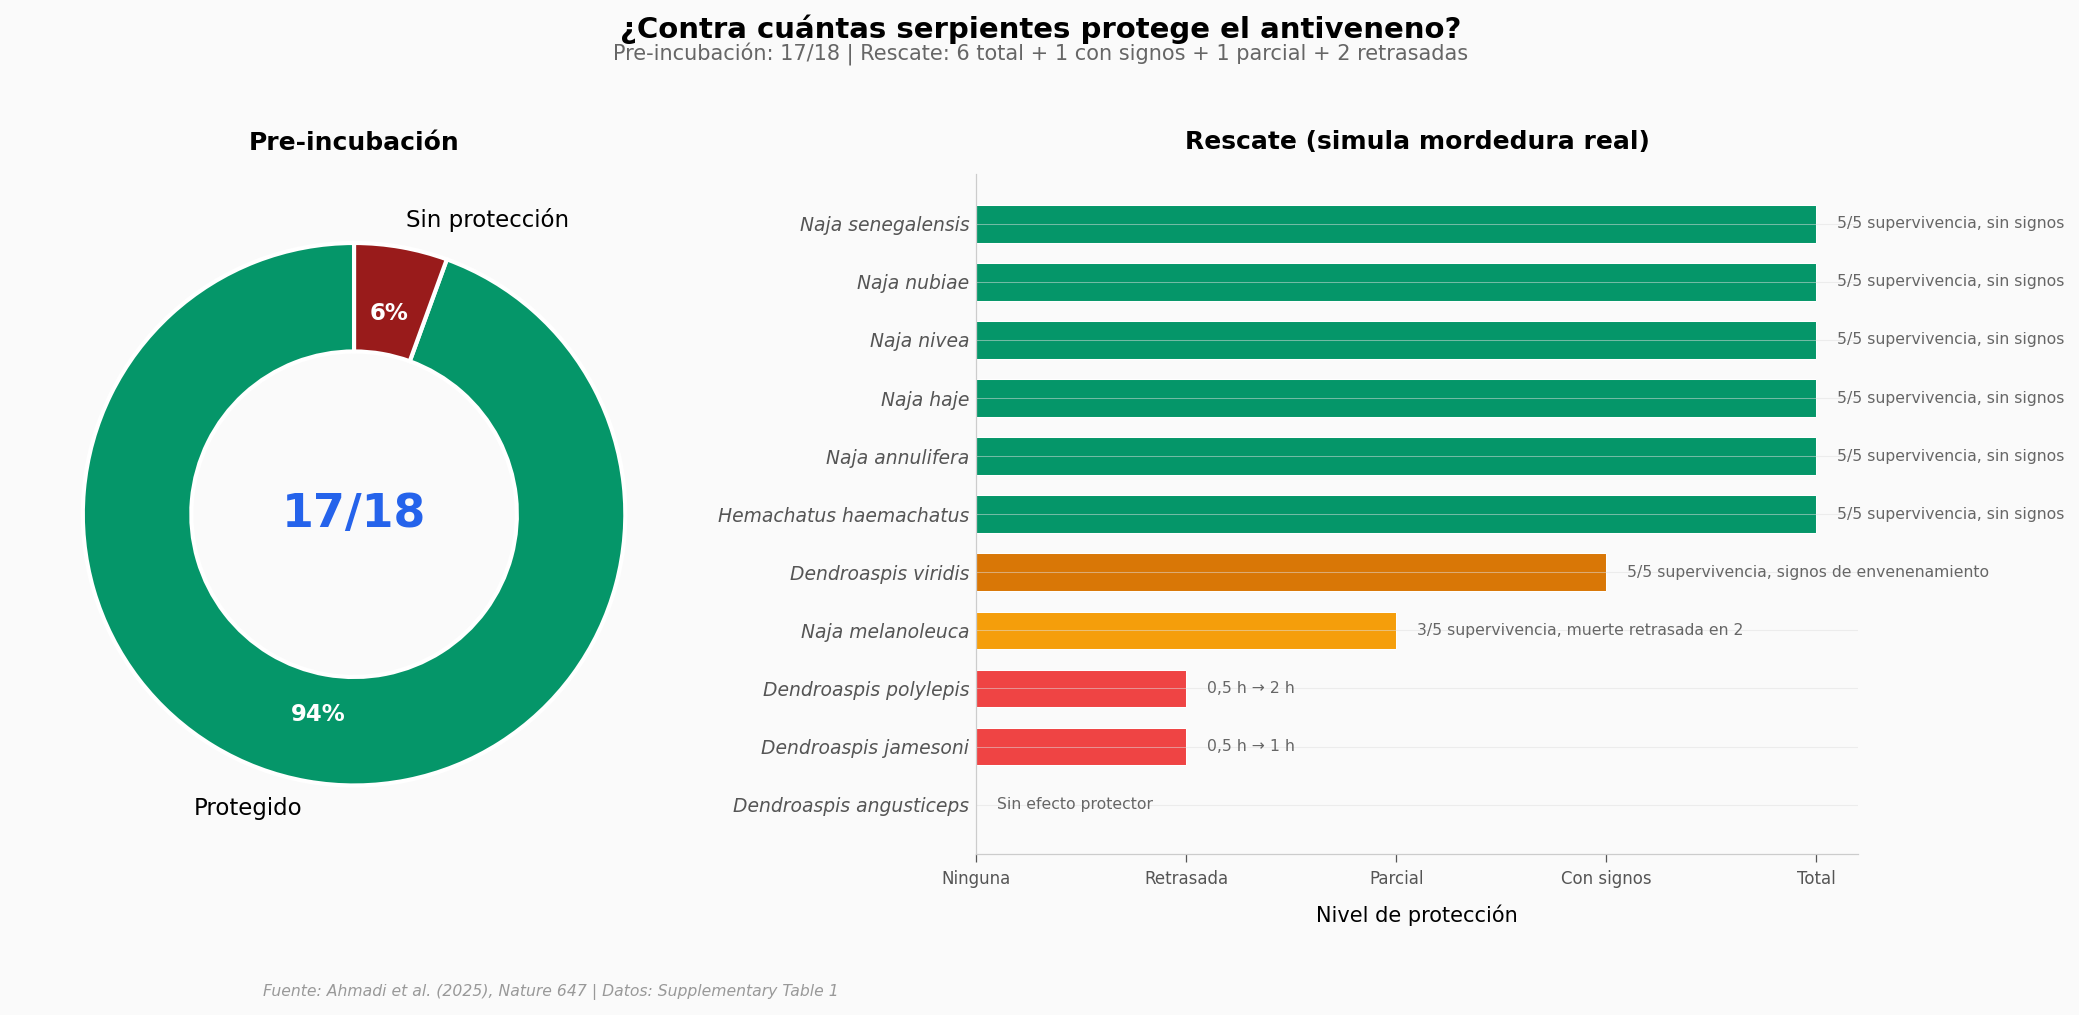

In [4]:
# Resultados in vivo: ¿contra cuántas serpientes protege?

# Solo especies testeadas en rescate
df_rescue = df_vivo[df_vivo['rescate'] != 'No testeado'].copy()

# Colores por resultado
result_colors = {
    'Protegido total': '#059669',      # Verde
    'Protegido (signos)': '#D97706',   # Amber
    'Parcial': '#F59E0B',              # Amarillo
    'Muerte retrasada': '#EF4444',     # Rojo claro
    'Sin protección': '#991B1B',       # Rojo oscuro
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.3]})

# Panel 1: Pre-incubación (donut chart)
pre_counts = df_vivo['pre_incubacion'].value_counts()
colors_pre = ['#059669', '#991B1B']
wedges, texts, autotexts = ax1.pie(
    [pre_counts.get('Protegido', 0), pre_counts.get('Sin protección', 0)],
    labels=['Protegido', 'Sin protección'],
    colors=colors_pre, autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, textprops={'fontsize': 11},
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)
autotexts[0].set_color('white')
autotexts[0].set_fontweight('bold')
autotexts[1].set_color('white')
autotexts[1].set_fontweight('bold')
ax1.text(0, 0, f'{N_PROTEGIDAS}/18', fontsize=22, fontweight='bold', ha='center', va='center',
         color=COLOR_3FTX)
ax1.set_title('Pre-incubación', fontsize=12, fontweight='bold', pad=12)

# Panel 2: Rescate (horizontal bar por especie)
species_rescue = df_rescue.sort_values('rescate_score', ascending=True)
y_pos = range(len(species_rescue))
colors_rescue = [result_colors.get(r, COLOR_OTRO) for r in species_rescue['rescate']]

ax2.barh(y_pos, species_rescue['rescate_score'], color=colors_rescue,
         edgecolor='white', linewidth=0.5, height=0.65)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([f'{sp}' for sp in species_rescue['especie']],
                    fontsize=9, fontstyle='italic')

# Anotar detalles
for i, (_, row) in enumerate(species_rescue.iterrows()):
    if row['rescate_detalle']:
        ax2.text(row['rescate_score'] + 0.1, i, row['rescate_detalle'],
                fontsize=7.5, va='center', color='#666666')

ax2.set_xlabel('Nivel de protección', fontsize=10)
ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_xticklabels(['Ninguna', 'Retrasada', 'Parcial', 'Con signos', 'Total'],
                    fontsize=8, rotation=0)
ax2.set_title('Rescate (simula mordedura real)', fontsize=12, fontweight='bold', pad=12)

fig.suptitle('¿Contra cuántas serpientes protege el antiveneno?',
             fontsize=14, fontweight='bold', y=1.04)
fig.text(0.5, 0.99, f'Pre-incubación: {N_PROTEGIDAS}/18 | Rescate: 6 total + 1 con signos + 1 parcial + 2 retrasadas + 1 sin protección',
         fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/resultados_in_vivo.png', dpi=200, bbox_inches='tight')
plt.show()

## El veneno real es una mezcla

Las serpientes no inyectan una sola toxina — inyectan un cocktail. Lo interesante es qué tan diverso es ese cocktail. ¿Las toxinas se reparten por igual, o una sola domina?

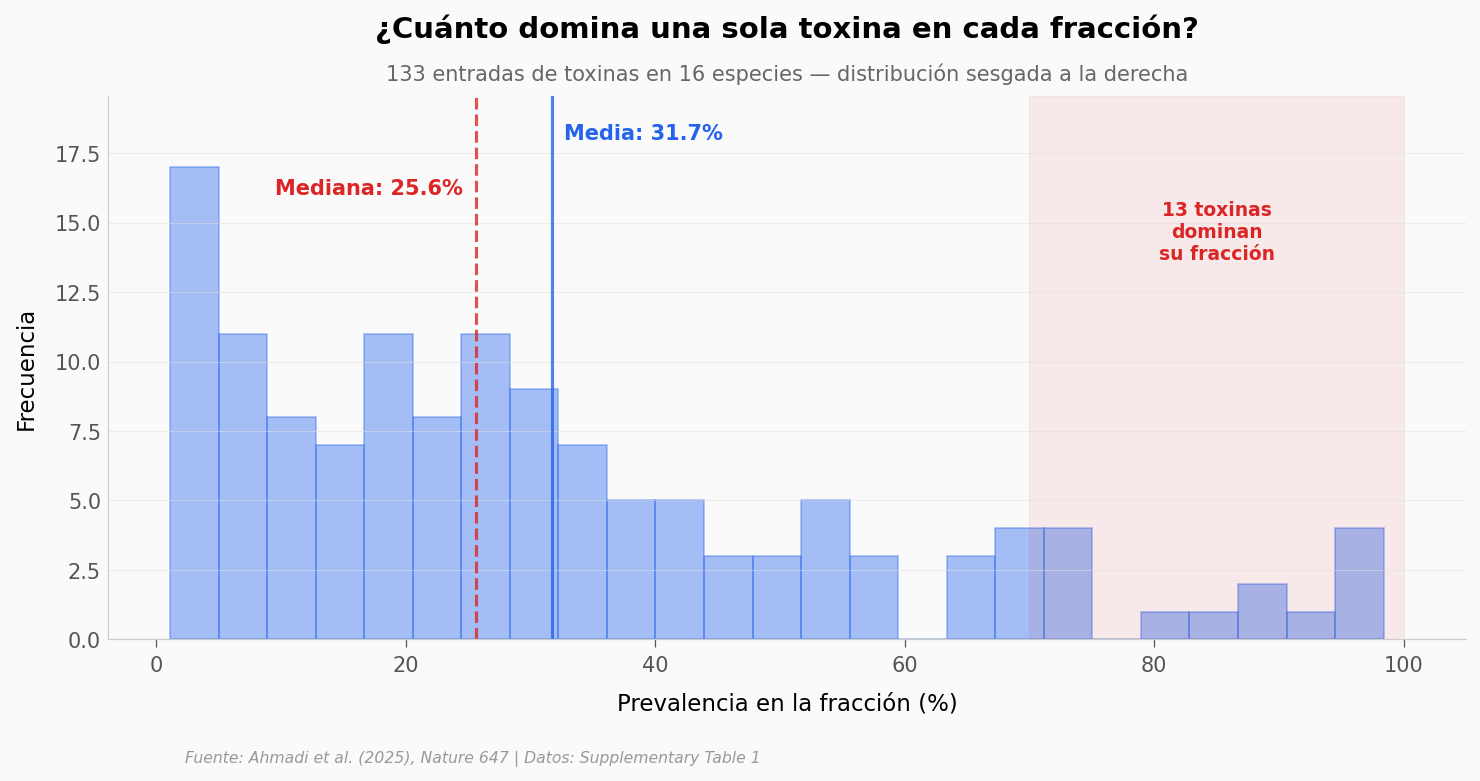

Prevalencia: media=31.7%, mediana=25.6%
IQR: 10.8–44.8%
Toxinas con >70% prevalencia: 13/133 (10%)


In [5]:
# Distribución de prevalencia: ¿las toxinas se reparten o una domina?
fig, ax = plt.subplots(figsize=(10, 5))

prevs = df['prevalencia_pct'].values
media = prevs.mean()
mediana = np.median(prevs)

n, bins, patches = ax.hist(prevs, bins=25, color=COLOR_3FTX, alpha=0.4,
                           edgecolor=COLOR_3FTX, linewidth=0.8)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Media y mediana
ax.axvline(x=media, color=COLOR_3FTX, linewidth=1.5, linestyle='-', alpha=0.8)
ax.axvline(x=mediana, color=COLOR_CTX, linewidth=1.5, linestyle='--', alpha=0.8)

# Inline labels
ax.text(media + 1, y_max * 0.92, f'Media: {media:.1f}%',
        fontsize=10, fontweight='bold', color=COLOR_3FTX)
ax.text(mediana - 1, y_max * 0.82, f'Mediana: {mediana:.1f}%',
        fontsize=10, fontweight='bold', color=COLOR_CTX, ha='right')

# Destacar toxinas dominantes (>70%)
mask_high = prevs > 70
if mask_high.any():
    ax.axvspan(70, 100, alpha=0.08, color=COLOR_CTX)
    n_dominant = mask_high.sum()
    ax.text(85, y_max * 0.7, f'{n_dominant} toxinas\ndominan\nsu fracción',
            fontsize=9, ha='center', color=COLOR_CTX, fontweight='bold')

ax.set_xlabel('Prevalencia en la fracción (%)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('¿Cuánto domina una sola toxina en cada fracción?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(prevs)} entradas de toxinas en 16 especies — distribución sesgada a la derecha',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/distribucion_prevalencia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Prevalencia: media={media:.1f}%, mediana={mediana:.1f}%")
print(f"IQR: {np.percentile(prevs, 25):.1f}–{np.percentile(prevs, 75):.1f}%")
print(f"Toxinas con >70% prevalencia: {mask_high.sum()}/{len(prevs)} ({mask_high.sum()/len(prevs)*100:.0f}%)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las toxinas de tres dedos (3FTx) dominan los venenos elapidas | ✅ | 115/133 entradas (86,5%) son 3FTx. Las 4 familias restantes (KUN, PLA₂, AVIT) suman 13,5% |
| Afronaja produce venenos citotóxicos, Uraeus y Dendroaspis neurotóxicos | ✅ | 28/33 entradas Afronaja son CTx. Uraeus: sNTx (9/41), CTx (18/41), Og (6), lNTx (6). Dendroaspis por AgTx+lNTx+sNTx |
| El antiveneno protege contra 17/18 especies en pre-incubación | ✅ (dato del paper) | No reproducible con nuestros datos — requiere curvas de supervivencia Kaplan-Meier |
| El antiveneno supera al comercial (Inoserp PAN-AFRICA) en modelos murinos | ✅ (dato del paper, preclínico) | En rescate y dermonecrosis en ratones; el recombinante fue superior en N. nigricollis — pendiente validación clínica |
| 8 nanobodies cubren 7 subfamilias de toxinas | ✅ | sNTx + lNTx + CTx + AgTx + OgXI + PLA₂ + KUN = 7, coincide con datos |

> **Limitaciones:** (1) Solo tenemos proteómica cuantitativa (prevalencia %), no curvas de supervivencia — los resultados in vivo son cualitativos del texto del paper. (2) D. angusticeps no tiene datos de proteómica en el supplementary. (3) Los ensayos in vivo son en ratones; la extrapolación a humanos requiere ensayos clínicos. (4) El modelo de rescate (5 min post-inyección) es más favorable que una mordedura real donde pueden pasar horas.

---

## Ahora tú

1. **¿Qué especie tiene el veneno más "concentrado"?** ¿En cuál la toxina dominante supera el 90% de prevalencia? Prueba con `df.groupby('especie')['prevalencia_pct'].max().sort_values(ascending=False).head(5)`
2. **¿Las mambas son más peligrosas?** Compara la diversidad de toxinas por subgénero: `df.groupby('subgenero')['familia_toxina'].nunique()` — ¿quién tiene más armas?
3. **¿Hay un patrón geográfico?** ¿Los subgéneros con veneno citotóxico (Afronaja) se concentran en alguna región?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuáles son las toxinas más dominantes? (prevalencia >80%)

top_toxinas = df[df['prevalencia_pct'] > 80].sort_values('prevalencia_pct', ascending=False)
print("Toxinas con prevalencia >80% en su fracción:")
print(top_toxinas[['especie', 'etiqueta', 'familia_toxina', 'prevalencia_pct']].to_string(index=False))

print(f"\n→ {len(top_toxinas)} toxinas dominantes en {top_toxinas['especie'].nunique()} especies")

# ¿Diversidad de subfamilias por subgénero?
print("\nDiversidad de subfamilias por subgénero:")
diversity = df.groupby('subgenero')['familia_toxina'].nunique().sort_values(ascending=False)
for subg, n in diversity.items():
    print(f"  {subg}: {n} subfamilias")

Toxinas con prevalencia >80% en su fracción:
               especie    etiqueta             familia_toxina  prevalencia_pct
       Naja annulifera      sNTx-7 sNTx (α-neurotoxina corta)            98.38
             Naja haje Other3FTx-3        Og (grupo huérfano)            98.00
       Naja annulifera      CTx-14           CTx (citotoxina)            97.22
        Naja anchietae      CTx-13           CTx (citotoxina)            96.49
   Dendroaspis viridis      sNTx-3 sNTx (α-neurotoxina corta)            94.33
  Dendroaspis jamesoni     Og XI-1  Og XI (grupo huérfano XI)            89.89
Hemachatus haemachatus       CTx-1           CTx (citotoxina)            88.02
 Dendroaspis polylepis       KUN-2     KUN (inhibidor Kunitz)            84.44
           Naja nubiae       CTx-9           CTx (citotoxina)            81.72

→ 9 toxinas dominantes en 8 especies

Diversidad de subfamilias por subgénero:
  Dendroaspis (mambas): 9 subfamilias
  Naja (Uraeus): 6 subfamilias
  Naja (Boulenge

---

### Créditos

- **Paper:** Ahmadi, S., Burlet, N. J., Benard-Valle, M. *et al.* "Nanobody-based recombinant antivenom for cobra, mamba and rinkhals bites." *Nature* **647**, 716–725 (2025). [DOI: 10.1038/s41586-025-09661-0](https://doi.org/10.1038/s41586-025-09661-0)
- **Datos:** Supplementary Table 1 (Source Data, MOESM1). Resultados in vivo extraídos del texto del paper.
- **Licencia:** [CC BY 4.0](http://creativecommons.org/licenses/by/4.0/) (Open Access)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)